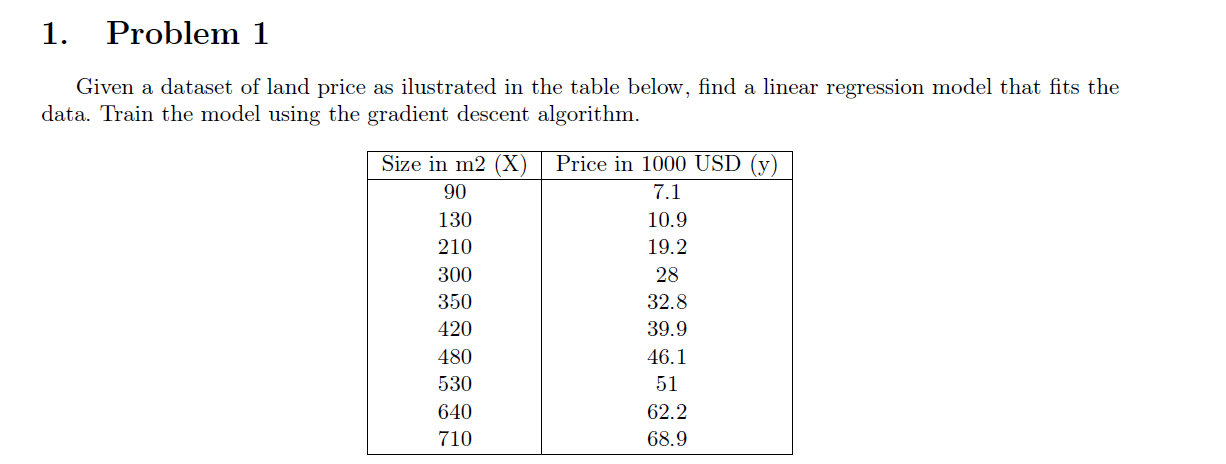

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import matplotlib.gridspec as gridspec

<Axes: >

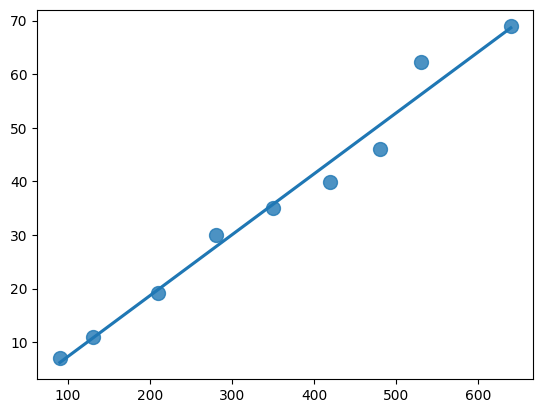

In [2]:
# Data from Problem 1
X = np.array([90, 130, 210, 280, 350, 420, 480, 530, 640])
y = np.array([7.1, 10.9, 19.2, 30, 35, 39.9, 46.1, 62.2, 68.9])
# plot data to scatter plot to visualize the data and decide on the model to fit
sns.regplot(x=X, y=y, ci=None, scatter_kws={"s": 100})

In [3]:
def grad(X: float, y: float, iter: int, w_lr: float, b_lr: float) -> tuple:
    '''
        One feature only \n
        feature and label will be scaled in this function
        >>> X: feature
        >>> y: label
        >>> iter: iteration
        >>> w_lr: weight learning rate
        >>> b_lr: bias learning rate
    '''
    X = X / np.max(X)
    
    w = 0
    b = 0

    for i in range(1, iter - 1):

        y_new = w * X + b
        weight = np.mean((y_new - y) * 2 * X)
        bias = np.mean((y_new - y) * 2)
        
        w = w - w_lr * weight
        b = b - b_lr * bias

    y_new = w * X + b
    loss = np.mean(pow(y - y_new, 2))

    return w, b, loss


In [4]:
X = np.array([90, 130, 210, 300, 350, 420, 480, 530, 640, 710])
y = np.array([7.1, 10.9, 19.2, 28.0, 32.8, 39.9, 46.1, 51.0, 62.2, 68.9])

a = grad(X, y, 10000, 0.01,0.01)
w = a[0]
b = a[1]
loss = a[2]
w = w / np.max(X)
print(f"Weight: {w:.6f}")
print(f"Bias: {b:.6f}")
print(f"loss: {loss:.6f}")
print(f"y = {w:.1f}x {b:.2f} ")


Weight: 0.099980
Bias: -1.982317
loss: 0.016885
y = 0.1x -1.98 


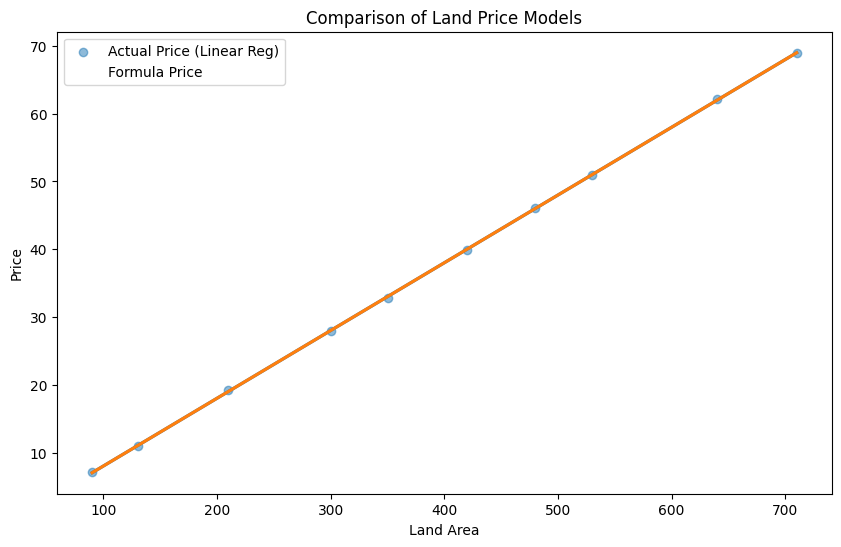

In [5]:
X = np.array([90, 130, 210, 300, 350, 420, 480, 530, 640, 710])
Y_actual = np.array([7.1, 10.9, 19.2, 28.0, 32.8, 39.9, 46.1, 51.0, 62.2, 68.9])

Y_formula = 0.09998 * X + -1.98 

plt.figure(figsize=(10, 6))

sns.regplot(x=X, y=Y_actual, ci=None, label='Actual Price (Linear Reg)', scatter_kws={'alpha':0.5})

sns.regplot(x=X, y=Y_formula, ci=None, label='Formula Price', marker="")

plt.xlabel('Land Area')
plt.ylabel('Price')
plt.title('Comparison of Land Price Models')
plt.legend()
plt.show()

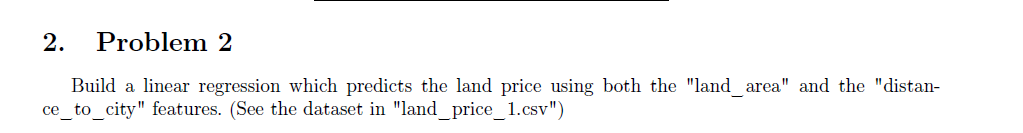

In [6]:
def grad(X1: float,X2:float , y: float, iter: int, w_lr: float, b_lr: float) -> tuple:
    '''
        One feature only \n
        feature and label will be scaled in this function
        >>> X1: Land area
        >>> X2: distance to city
        >>> y: label
        >>> iter: iteration
        >>> w_lr: weight learning  X1 and X2
        >>> b_lr: bias learning rate
    '''
    X1 = X1 / np.max(X1)
    X2 = X2 / np.max(X2)
    
    w1 = 0
    w2 = 0
    b = 0

    for i in range(1, iter - 1):

        y_new = w1 * X1 + w2 * X2 + b
        
        weight1 = np.mean((y_new - y) * 2 * X1)
        weight2 = np.mean((y_new - y) * 2 * X2)
        
        bias = np.mean((y_new - y) * 2)
        
        w1 = w1 - w_lr * weight1
        w2 = w2 - w_lr * weight2
        b = b - b_lr * bias

    y_new = w1 * X1 + w2 * X2 + b
    loss = np.mean(pow(y - y_new, 2))

    return w1,w2, b, loss


In [7]:
# Load the data
df = pd.read_csv('land_price_1.csv')
X1 = df['land_area'].values
X2 = df['dist_to_city'].values
y = df['price'].values


a = grad(X1,X2, y, 10000, 0.01, 0.01)
w1 = a[0]
w2 = a[1]
b = a[2]
loss = a[3]
w1 = w1 / np.max(X1)
w2 = w2 /np.max(X2)
print(f"Weight1: {w1:.6f}")
print(f"Weight2: {w2:.6f}")
print(f"Bias: {b:.6f}")
print(f"loss: {loss:.6f}")
print(f"y = {w1:.5f} x1 {w2:.5f} x2 + {b:.2f} ")



Weight1: 0.100177
Weight2: -2.010959
Bias: 29.916129
loss: 0.364475
y = 0.10018 x1 -2.01096 x2 + 29.92 


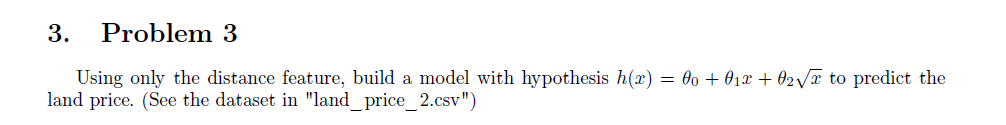

<Axes: >

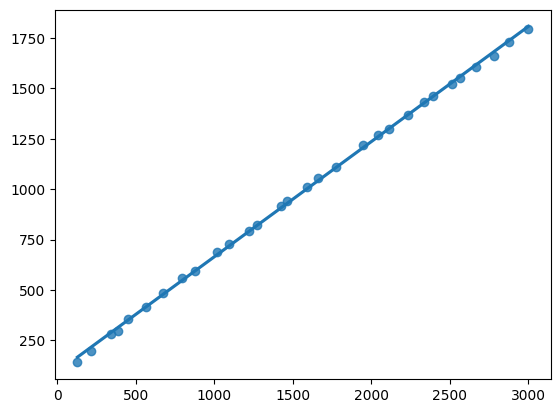

In [8]:
# Load the data
df = pd.read_csv('land_price_2.csv')
X = df['land_area'].values
Y = df['price'].values
sns.regplot(x=X,y=Y,ci = None)

is a liner regression

In [9]:
def grad(X_raw, y_raw, iterations, lr):
    x_max = np.max(X_raw)
    y_max = np.max(y_raw)
    
    X = X_raw / x_max
    y = y_raw / y_max
    
    w1, w2, b = 0.0, 0.0, 0.0
    n = len(X)
    sqrt_X = np.sqrt(X)

    for i in range(iterations):
        y_pred = w1 * X + w2 * sqrt_X + b
        
        error = y_pred - y
        dw1 = (2/n) * np.sum(error * X)
        dw2 = (2/n) * np.sum(error * sqrt_X)
        db = (2/n) * np.sum(error)
        
        w1 -= lr * dw1
        w2 -= lr * dw2
        b -= lr * db
    final_pred = w1 * X + w2 * sqrt_X + b
    loss = np.mean((y - final_pred)**2)

    w1_final = w1 * (y_max / x_max)
    w2_final = w2 * (y_max / np.sqrt(x_max))
    b_final = b * y_max

    return w1_final, w2_final, b_final, loss

df = pd.read_csv('land_price_2.csv')
X = df['land_area'].values
y = df['price'].values

w1, w2, b, loss = grad(X, y, 10000, 0.1)

print(f"Weight1: {w1:.6f}")
print(f"Weight2: {w2:.6f}")
print(f"Bias: {b:.6f}")
print(f"y = {w1:.5f}x + {w2:.5f}√x + {b:.2f}")

Weight1: 0.481133
Weight2: 6.385668
Bias: -5.914964
y = 0.48113x + 6.38567√x + -5.91


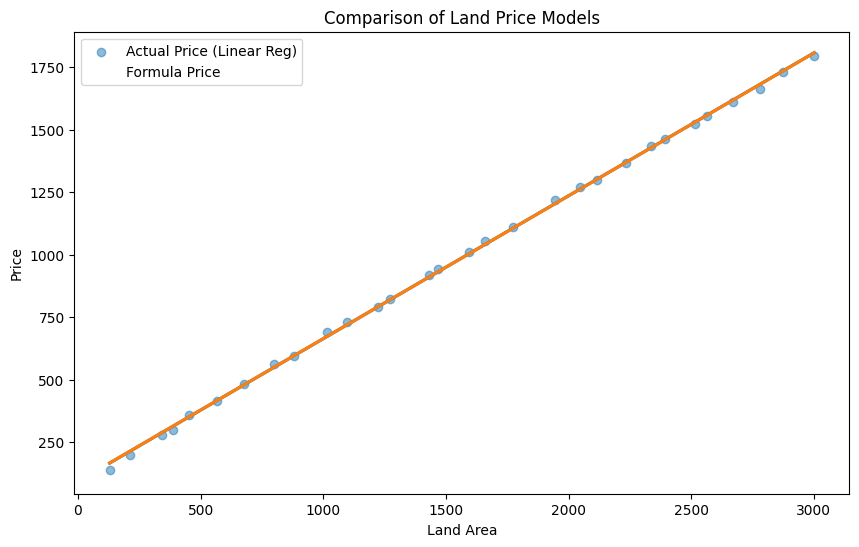

In [10]:
df = pd.read_csv('land_price_2.csv')
X = df['land_area'].values
Y_actual = df['price'].values
Y_formula = 0.48113 * X + 6.38567 * np.sqrt(X) + -5.91

plt.figure(figsize=(10, 6))

sns.regplot(x=X, y=Y_actual, ci=None, label='Actual Price (Linear Reg)', scatter_kws={'alpha':0.5})

sns.regplot(x=X, y=Y_formula, ci=None, label='Formula Price', marker="")

plt.xlabel('Land Area')
plt.ylabel('Price')
plt.title('Comparison of Land Price Models')
plt.legend()
plt.show()

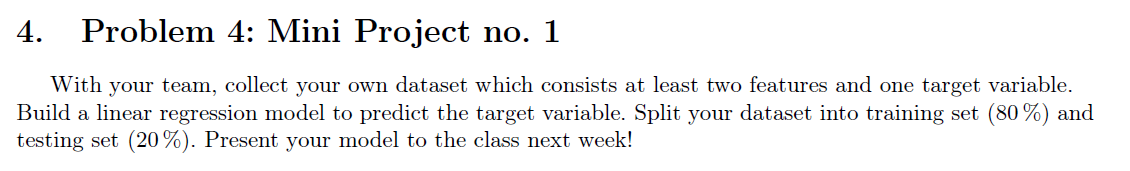

We're doing stress prediction 
* label (stress level)
* Features(study hour,exam frequacy,sleep hours,Finantial pressure,Relationship)

<div style='background: green; color: white; padding: 19px; border-radius: 10px; text-align: center'>
<h2 style="margin: 0">Data description</h2>
</div>


In [11]:
student_stress = pd.read_csv("student_stress_survey_responses.csv")
student_stress.head()

,Timestamp,Score,"On average, how many hours do you study per week (School and self-study) ? (Ex. 35)",How many exams or quizzes do you have per month? (Ex.5),"On average, how many hours do you sleep per night? (Ex.8)",How much financial pressure do you currently feel ?,"On a scale of 1-10, how would you rate your overall stress level this semester ?"
0,3/2/2026 21:40:44,0 / 40,50,6,6,4,8
1,3/2/2026 21:41:00,0 / 40,15,5,5,4,7
2,3/2/2026 21:42:17,0 / 40,12,12,12,3,7
3,3/2/2026 21:42:34,0 / 40,25,6,6,3,7
4,3/2/2026 21:43:25,0 / 40,36,4,6,3,6


<div style='background: steelblue; color: white; padding: 19px; border-radius: 10px; text-align: center'>
<h2 style="margin: 0">Data cleaning</h2>
</div>


In [12]:
student_stress.columns

Index(['Timestamp', 'Score',
       'On average, how many hours do you study per week  (School and self-study)    ? (Ex. 35)',
       'How many exams or quizzes do you have per month? (Ex.5)',
       'On average, how many hours do you sleep per night? (Ex.8)',
       'How much financial pressure do you currently feel ?',
       'On a scale of 1-10, how would you rate your overall stress level this semester ? '],
      dtype='object')

In [13]:
student_stress = student_stress.drop(columns=['Timestamp','Score'])
student_stress = student_stress.rename(columns={'On average, how many hours do you study per week  (School and self-study)    ? (Ex. 35)': 'Study_Hours',
                                                'How many exams or quizzes do you have per month? (Ex.5)': 'Exams_Per_Month',
                                                'On average, how many hours do you sleep per night? (Ex.8)': 'Sleep_Hours',
                                                'How much financial pressure do you currently feel ?': 'Financial_Pressure',
                                                'How many hours do you spend on leisure activities?': 'Leisure_Hours',
                                                'On a scale of 1-10, how would you rate your overall stress level this semester ? ': 'Stress_Level'})
student_stress.head()

,Study_Hours,Exams_Per_Month,Sleep_Hours,Financial_Pressure,Stress_Level
0,50,6,6,4,8
1,15,5,5,4,7
2,12,12,12,3,7
3,25,6,6,3,7
4,36,4,6,3,6


In [14]:
student_stress['Study_Hours'].unique()

array(['50', '15', '12', '25', '36', '30', '45', '40', '52', '11', '10',
       '26', '7', '65', '32-36', '20', '32', '48', '24h'], dtype=object)

In [15]:
student_stress['Study_Hours'] = student_stress['Study_Hours'].replace('24h', '24')
student_stress['Study_Hours'] = student_stress['Study_Hours'].replace('32-36', '34')
student_stress['Study_Hours'] = student_stress['Study_Hours'].astype(int)

In [16]:
student_stress['Exams_Per_Month'].unique()

array(['6', '5', '12', '4', '3', '8', '6-7', '25', '10', '2', '7'],
      dtype=object)

In [17]:
student_stress['Exams_Per_Month'] = student_stress['Exams_Per_Month'].replace('6-7', '6')
student_stress['Exams_Per_Month'] = student_stress['Exams_Per_Month'].astype(int)

In [18]:
student_stress['Sleep_Hours'].unique()

array(['6', '5', '12', '11', '5-7', '8', '3', '7', '6-7', '6h'],
      dtype=object)

In [19]:
student_stress['Sleep_Hours'] = student_stress['Sleep_Hours'].replace('5-7', '6')
student_stress['Sleep_Hours'] = student_stress['Sleep_Hours'].replace('6-7', '6.5')
student_stress['Sleep_Hours'] = student_stress['Sleep_Hours'].replace('6h', '6')
student_stress['Sleep_Hours'] = student_stress['Sleep_Hours'].astype(float)

In [20]:
student_stress['Financial_Pressure'].unique()

array([4, 3, 2, 5])

In [21]:
student_stress['Stress_Level'].unique()

array([ 8,  7,  6,  5, 10,  9])

In [22]:
student_stress.shape

(42, 5)

In [23]:
def droping_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
student_stress = droping_outliers(student_stress, 'Study_Hours')
student_stress = droping_outliers(student_stress, 'Exams_Per_Month')
student_stress = droping_outliers(student_stress, 'Sleep_Hours')
student_stress = droping_outliers(student_stress, 'Financial_Pressure')
student_stress = droping_outliers(student_stress, 'Stress_Level')

In [24]:
student_stress.columns

Index(['Study_Hours', 'Exams_Per_Month', 'Sleep_Hours', 'Financial_Pressure',
       'Stress_Level'],
      dtype='object')

<div style='background: pink; color: white; padding: 19px; border-radius: 10px; text-align: center'>
<h2 style="margin: 0">Descriptive Statistics</h2>
</div>


In [25]:
student_stress.describe()

,Study_Hours,Exams_Per_Month,Sleep_Hours,Financial_Pressure,Stress_Level
count,32.000000,32.000000,32.000000,32.000000,32.000000
mean,29.843750,4.656250,5.953125,3.406250,6.968750
std,13.545882,1.638437,0.676320,0.945597,1.062085
min,7.000000,2.000000,5.000000,2.000000,5.000000
25%,18.750000,3.000000,5.750000,3.000000,6.000000
50%,31.000000,5.000000,6.000000,3.000000,7.000000
75%,40.000000,6.000000,6.000000,4.000000,8.000000
max,52.000000,8.000000,7.000000,5.000000,9.000000


<div style='background: gold; color: white; padding: 19px; border-radius: 10px; text-align: center'>
<h2 style="margin: 0">Exploratory Data Analysis</h2>
</div>


In [26]:
Study_Hours = student_stress['Study_Hours'].values
Exams_Per_Month = student_stress['Exams_Per_Month'].values
Sleep_Hours = student_stress['Sleep_Hours'].values
Financial_Pressure = student_stress['Financial_Pressure'].values
Stress_Level = student_stress['Stress_Level'].values #lebel

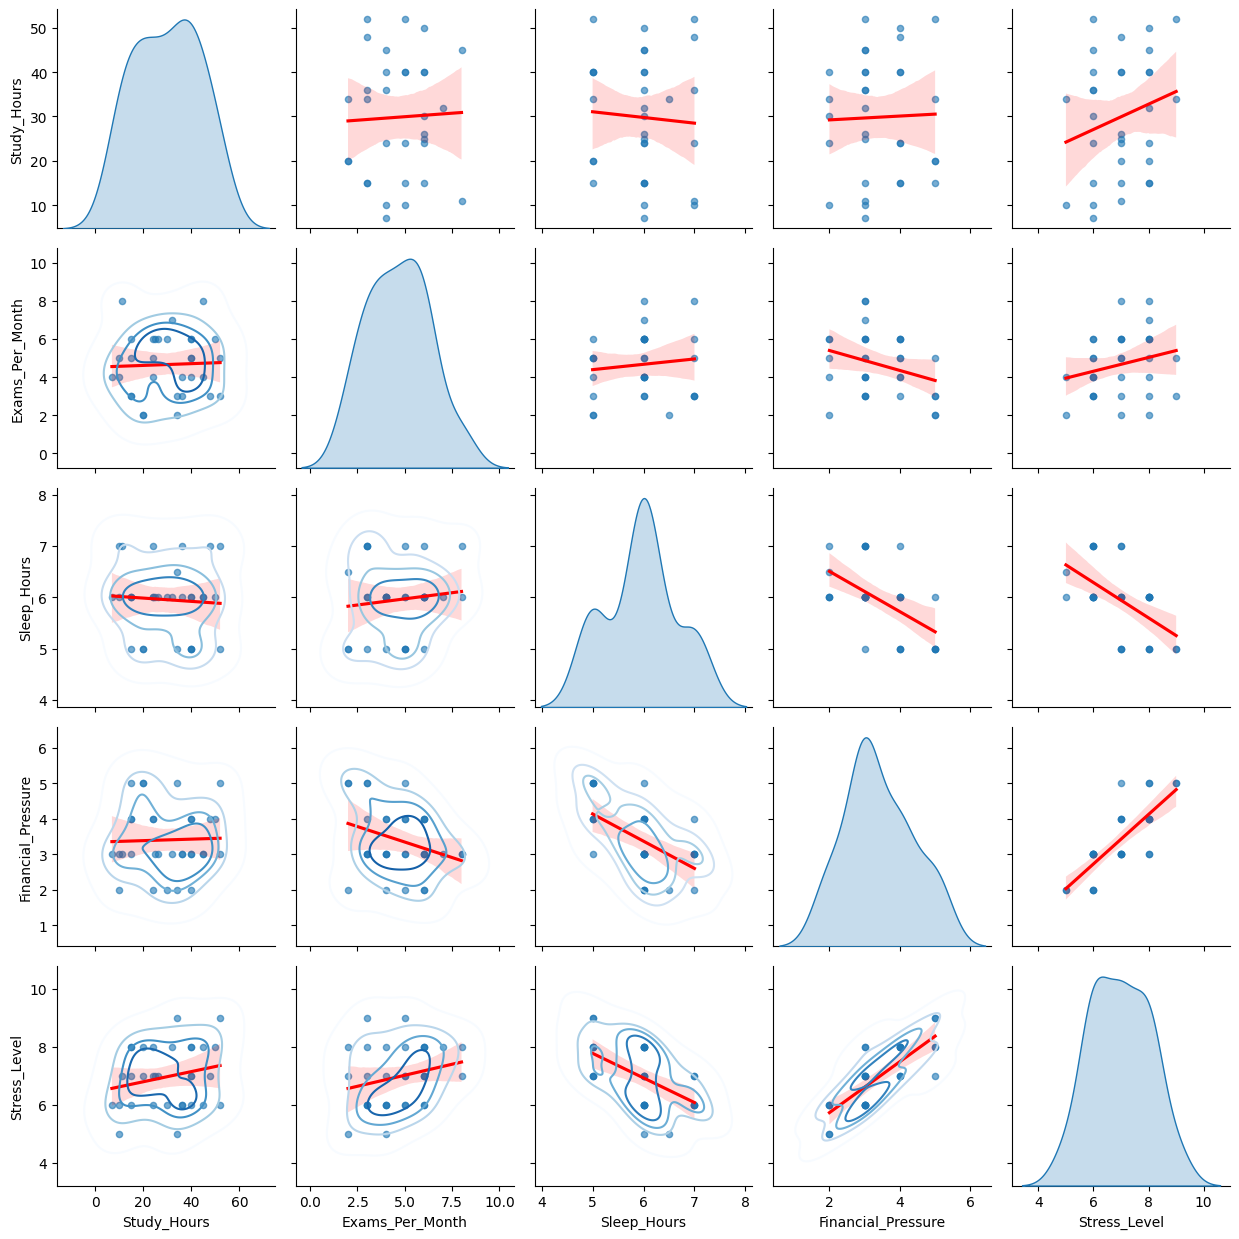

In [27]:
g = sns.pairplot(student_stress,
                 kind='reg',          # <– adds the trend/regression line
                 diag_kind='kde',
                 plot_kws={
                     'scatter_kws': {'s':20,'alpha':.6},
                     'line_kws':    {'color':'red'}})   # line style

# you can still overlay contours if you like
g.map_lower(sns.kdeplot, levels=5, cmap='Blues', fill=False)

plt.tight_layout()
plt.show()

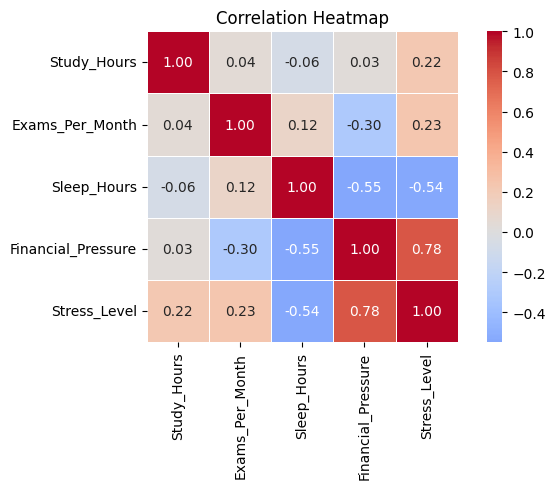

In [28]:
# Correlation heatmap
plt.figure(figsize=(7, 5))
corr = student_stress.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


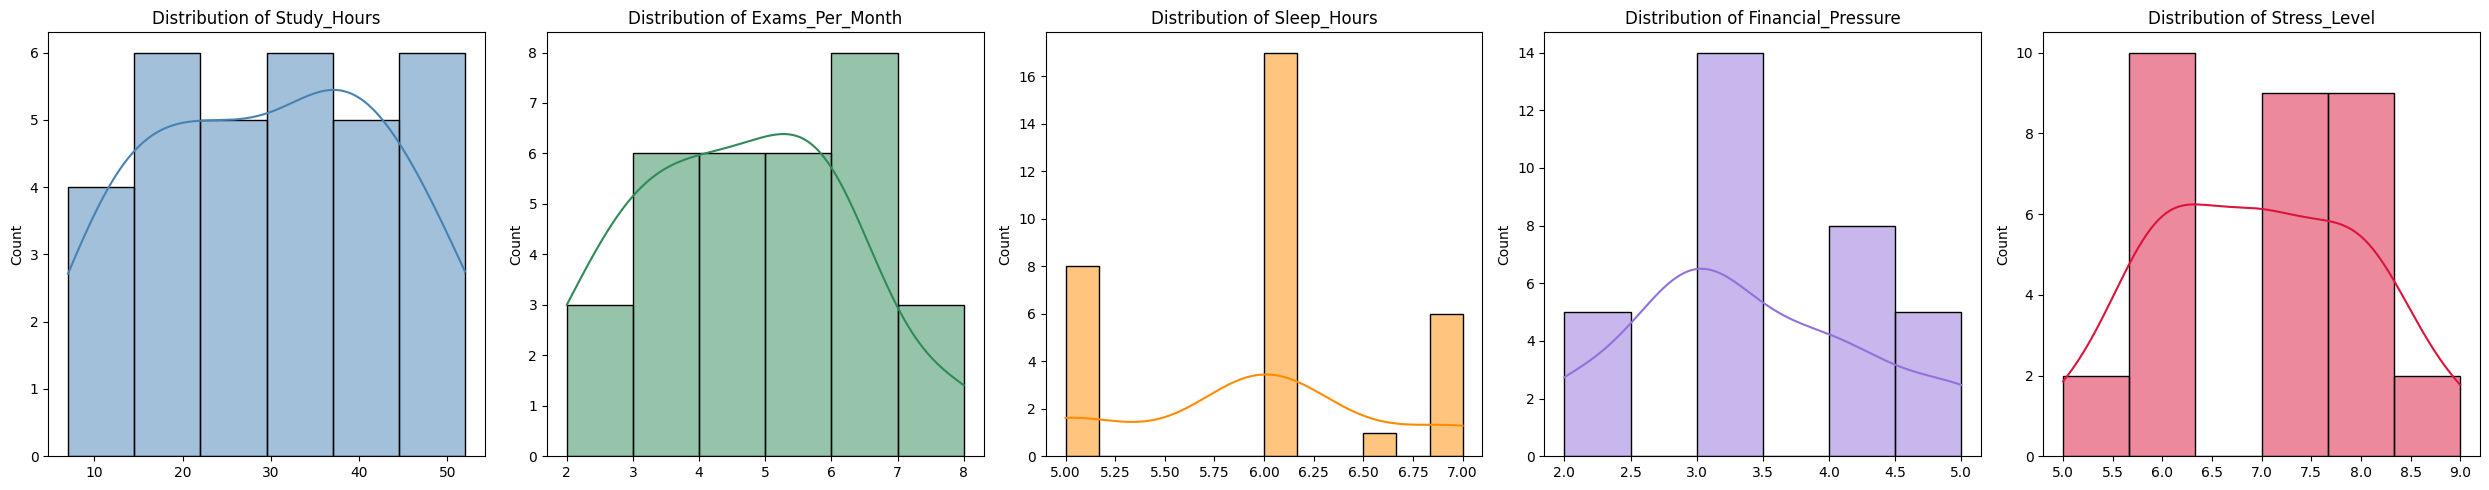

In [29]:
# Distribution of each variable
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
cols = ['Study_Hours', 'Exams_Per_Month', 'Sleep_Hours', 'Financial_Pressure', 'Stress_Level']
colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple', 'crimson']
for i, (col, color) in enumerate(zip(cols, colors)):
    sns.histplot(data=student_stress, x=col, kde=True, ax=axes[i], color=color)
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')
plt.tight_layout()
plt.show()


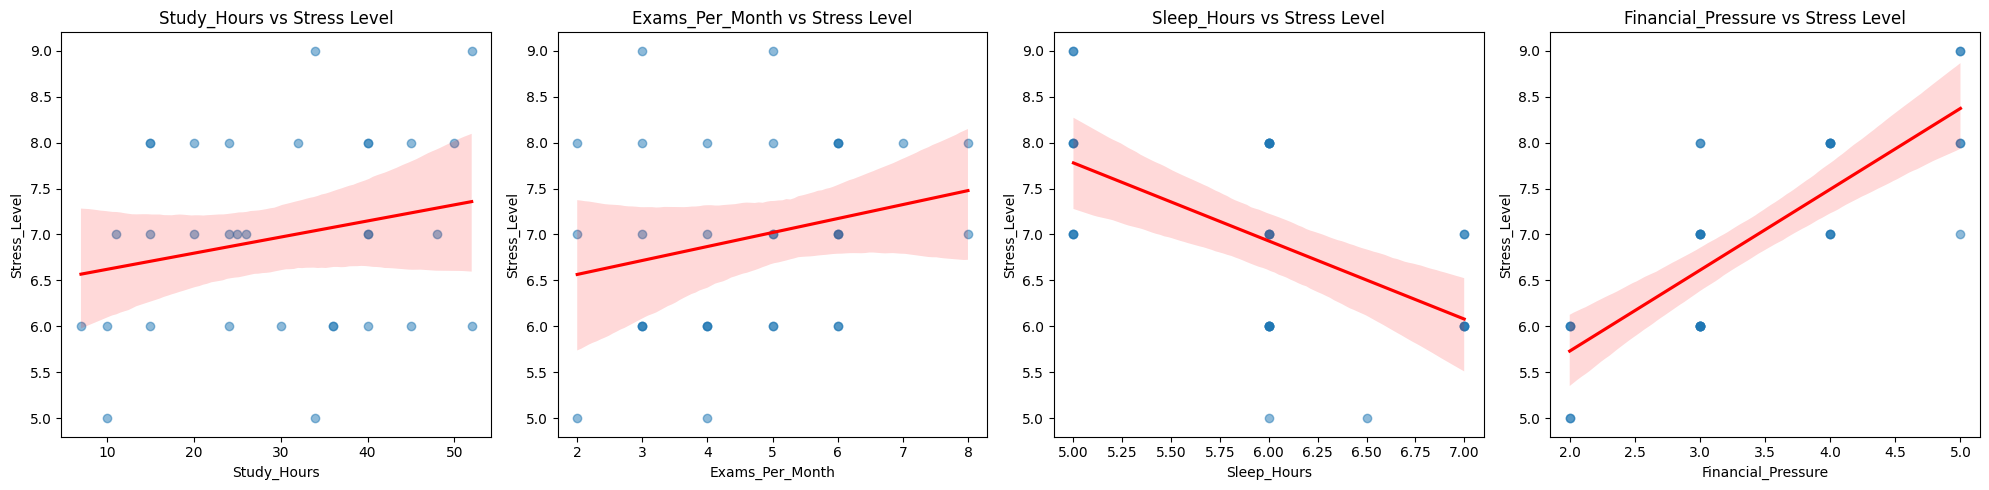

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
features = ['Study_Hours', 'Exams_Per_Month', 'Sleep_Hours', 'Financial_Pressure']

for i, col in enumerate(features):
    ax = axes.flatten()[i]
    # regplot handles both the dots and the trend line
    sns.regplot(data=student_stress, x=col, y='Stress_Level', ax=ax, 
                line_kws={"color": "red"}, scatter_kws={"alpha": 0.5})
    ax.set_title(f'{col} vs Stress Level')

plt.tight_layout()
plt.show()

<div style='background: lime; color: white; padding: 19px; border-radius: 10px; text-align: center'>
<h2 style="margin: 0">Regression model</h2>
</div>


In [31]:
from sklearn.model_selection import train_test_split

features = ['Study_Hours', 'Sleep_Hours', 'Financial_Pressure', 'Exams_Per_Month']
X_all = student_stress[features].values.astype(float)
y_all = student_stress['Stress_Level'].values.astype(float)

# ── 80 / 20 split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=33)

# ── Scale using TRAINING statistics only (prevents data leakage) ─────────
max_X = np.max(X_train, axis=0)
max_y = np.max(y_train)

X_train_s = X_train / max_X
y_train_s = y_train / max_y
X_test_s  = X_test  / max_X   # scale test with training max

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 25
Testing  samples : 7


In [32]:
# ── Gradient descent ─────────────────────────────────────────────────────
W = np.zeros(len(features))
b = 0.0
lr = 0.01
iterations = 10000
losses_p4 = []

for i in range(iterations):
    y_pred_s = X_train_s @ W + b
    error    = y_pred_s - y_train_s
    dW = (2 / len(X_train_s)) * (X_train_s.T @ error)
    db = (2 / len(y_train_s)) * np.sum(error)
    W -= lr * dW
    b -= lr * db
    if i % 1000 == 0:
        losses_p4.append(np.mean(error ** 2))

# ── Un-scale weights back to original units ───────────────────────────────
W_final = (W * max_y) / max_X
b_final = b * max_y

for feat, wt in zip(features, W_final):
    print(f"  {feat:25s}: {wt:+.6f}")
print(f"  {'Bias':25s}: {b_final:+.6f}")


  Study_Hours              : +0.012382
  Sleep_Hours              : -0.074217
  Financial_Pressure       : +1.015747
  Exams_Per_Month          : +0.371858
  Bias                     : +1.865203


In [33]:
# ── Evaluation on TEST SET (the honest score) ─────────────────────────────
y_test_pred_s = X_test_s @ W + b
y_test_pred   = y_test_pred_s * max_y   # un-scale to real units

ss_res  = np.sum((y_test - y_test_pred) ** 2)
ss_tot  = np.sum((y_test - np.mean(y_test)) ** 2)
r2_test = 1 - ss_res / ss_tot
mse_test = np.mean((y_test - y_test_pred) ** 2)
mae_test = np.mean(np.abs(y_test - y_test_pred))
rmse_test = np.sqrt(mse_test)

print("=" * 40)
print("  TEST SET METRICS")
print("=" * 40)
print(f"  R²   = {r2_test:.4f}  ({r2_test*100:.2f}% variance explained)")
print(f"  MSE  = {mse_test:.4f}")
print(f"  RMSE = {rmse_test:.4f}  (same units as Stress Level)")
print(f"  MAE  = {mae_test:.4f}  (avg prediction error in stress points)")


  TEST SET METRICS
  R²   = 0.8091  (80.91% variance explained)
  MSE  = 0.1480
  RMSE = 0.3848  (same units as Stress Level)
  MAE  = 0.3424  (avg prediction error in stress points)


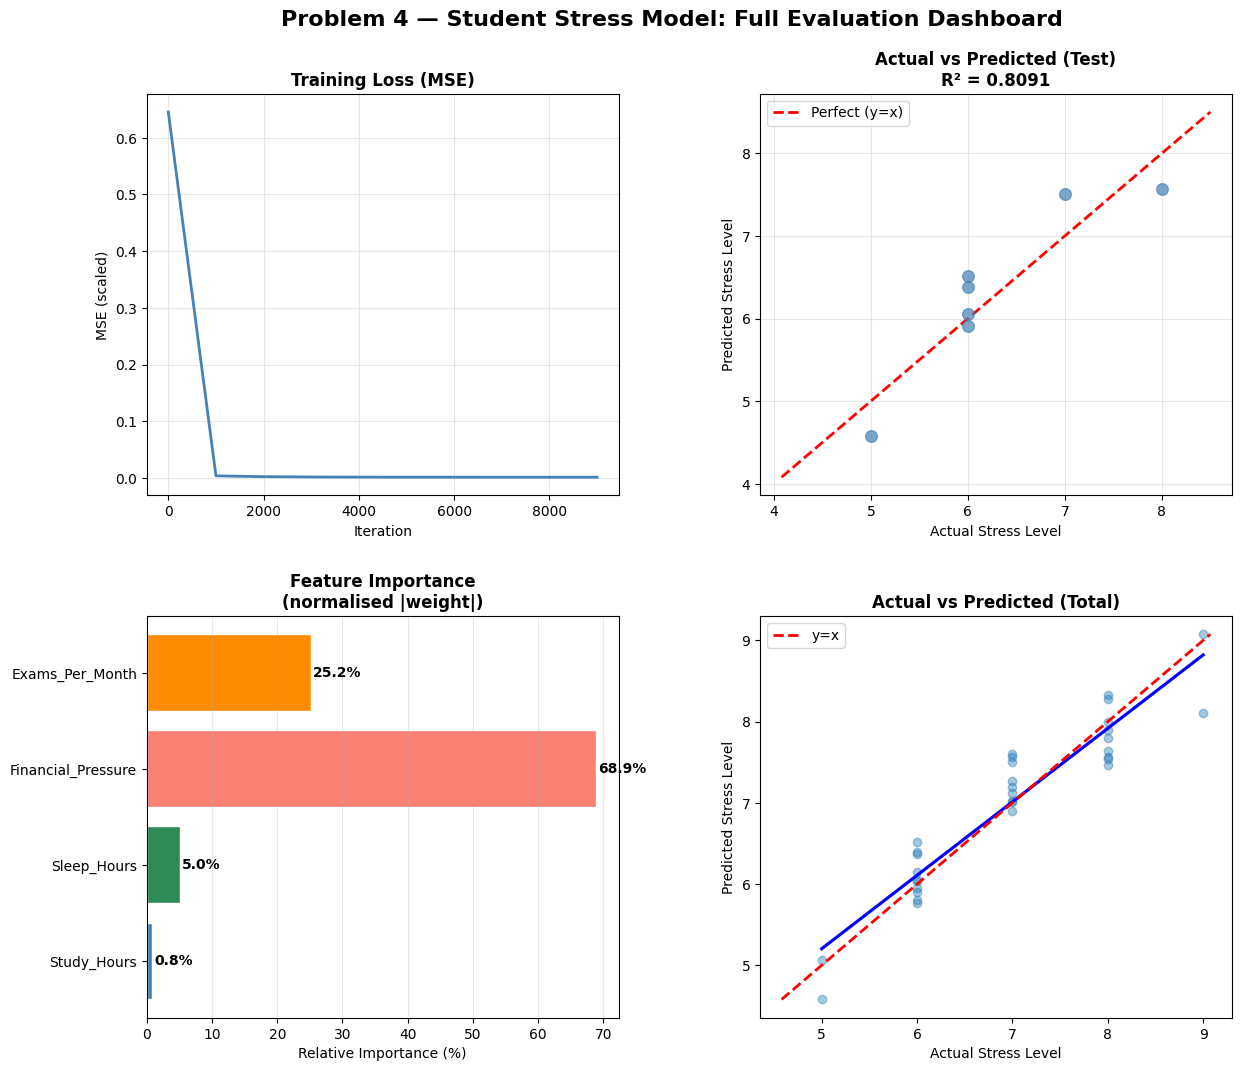

In [49]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns

# ════════════════════════════════════════════════════════════════════════
#  COMPREHENSIVE EVALUATION DASHBOARD (FIXED & UNIFIED)
# ════════════════════════════════════════════════════════════════════════

# Increase figure size to fit the 2x2 layout properly
fig = plt.figure(figsize=(14, 12))
# Define a 2x2 grid
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

# ── 1. Training Loss Curve ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0]) 
ax1.plot(np.arange(len(losses_p4)) * 1000, losses_p4, color='steelblue', linewidth=2)
ax1.set_title('Training Loss (MSE)', fontweight='bold')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('MSE (scaled)')
ax1.grid(alpha=0.3)

# ── 2. Actual vs Predicted — Scatter ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_test, y_test_pred, s=70, color='steelblue', alpha=0.7, zorder=5)

low = min(y_test.min(), y_test_pred.min()) - 0.5
high = max(y_test.max(), y_test_pred.max()) + 0.5
ax2.plot([low, high], [low, high], 'r--', linewidth=2, label='Perfect (y=x)')

ax2.set_xlabel('Actual Stress Level')
ax2.set_ylabel('Predicted Stress Level')
ax2.set_title(f'Actual vs Predicted (Test)\nR² = {r2_test:.4f}', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# ── 3. Feature Importance ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0]) # Moved to row 1, col 0
importance = np.abs(W_final) / np.sum(np.abs(W_final)) * 100
feat_colors = ['steelblue', 'seagreen', 'salmon', 'darkorange']

bars2 = ax3.barh(features, importance, color=feat_colors, edgecolor='white')
for bar, val in zip(bars2, importance):
    ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax3.set_xlabel('Relative Importance (%)')
ax3.set_title('Feature Importance\n(normalised |weight|)', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# ── 4. Regression Plot (The sns.regplot part) ───────────────────────────
ax4 = fig.add_subplot(gs[1, 1]) # Moved to row 1, col 1
# Calculate predictions for the whole set if needed
stress_pred = (0.012382 * Study_Hours - 0.074217 * Sleep_Hours + 
               1.015747 * Financial_Pressure + 0.371858 * Exams_Per_Month + 1.865203)

sns.regplot(x=Stress_Level, y=stress_pred, ci=None, ax=ax4, 
            scatter_kws={'alpha':0.4}, line_kws={'color':'blue'})

# Add y=x line for reference
min_val = min(Stress_Level.min(), stress_pred.min())
max_val = max(Stress_Level.max(), stress_pred.max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x')

ax4.set_xlabel('Actual Stress Level')
ax4.set_ylabel('Predicted Stress Level')
ax4.set_title('Actual vs Predicted (Total)', fontweight='bold')
ax4.legend()

# Final layout adjustments
plt.suptitle('Problem 4 — Student Stress Model: Full Evaluation Dashboard',
             fontsize=16, fontweight='bold', y=0.95)

plt.show()